# Chapter 4 — Vector Applications

## Learning Objectives

This notebook connects vector operations to correlation, cosine similarity, filtering, and k-means clustering.

## Theoretical Explanation

Many data science procedures are built from vector operations. Pearson correlation is a normalized dot product after mean-centering. Cosine similarity is also a normalized dot product, but without mean-centering. Filtering uses local dot products between a signal and a kernel. K-means uses vector distances to assign points to centroids.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Correlation and Cosine Similarity

In [2]:
x = np.array([0,1,2,3])
y = x + 10
corr = np.dot(x-x.mean(), y-y.mean()) / (norm(x-x.mean())*norm(y-y.mean()))
cos = np.dot(x,y)/(norm(x)*norm(y))
print('Pearson correlation:', corr)
print('Cosine similarity:', round(cos, 4))

Pearson correlation: 0.9999999999999998
Cosine similarity: 0.8558


### Output Interpretation

Correlation is 1 because the variables change together perfectly after mean-centering. Cosine similarity is below 1 because the raw vectors have different offsets.

## 2. Simple Time-Series Edge Detector

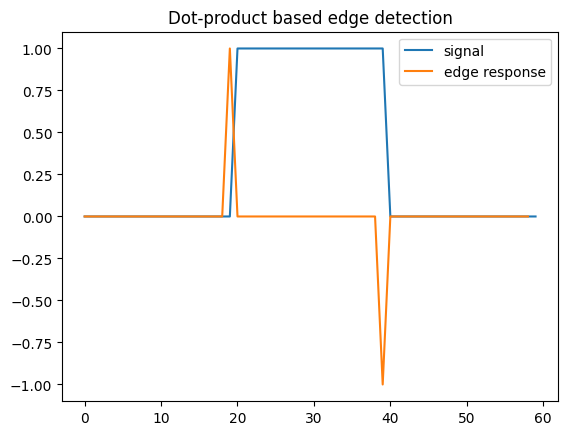

In [3]:
signal = np.r_[np.zeros(20), np.ones(20), np.zeros(20)]
kernel = np.array([-1, 1])
filtered = np.array([np.dot(kernel, signal[i:i+2]) for i in range(len(signal)-1)])
plt.plot(signal, label='signal')
plt.plot(np.r_[filtered, np.nan], label='edge response')
plt.legend(); plt.title('Dot-product based edge detection')
plt.show()

### Output Interpretation

The filter output spikes where the signal changes sharply. This is the same conceptual mechanism used in convolution and feature detection.

## 3. Minimal k-Means from Scratch

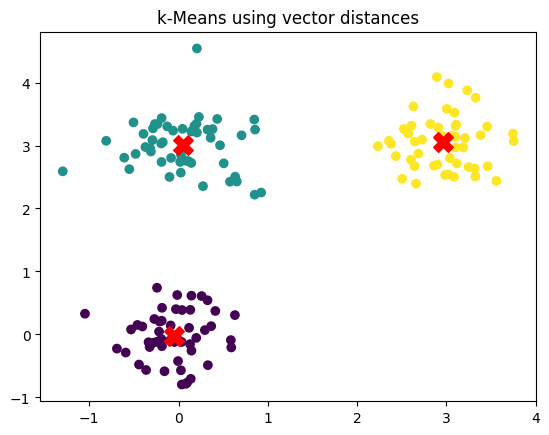

In [4]:
rng = np.random.RandomState(RANDOM_STATE)
data = np.vstack([rng.normal([0,0],.4,(50,2)), rng.normal([3,3],.4,(50,2)), rng.normal([0,3],.4,(50,2))])
k=3
centroids = data[rng.choice(len(data), k, replace=False)]
for _ in range(8):
    dists = np.array([np.sum((data-c)**2,axis=1) for c in centroids]).T
    labels = np.argmin(dists, axis=1)
    centroids = np.array([data[labels==i].mean(axis=0) for i in range(k)])
plt.scatter(data[:,0], data[:,1], c=labels, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.title('k-Means using vector distances')
plt.show()

### Output Interpretation

Each point is assigned to the nearest centroid. The centroids update to the mean of assigned points, showing how vector norms and averaging drive k-means.

## Extended Study Notes

The central learning objective is not only to run code, but to connect the numerical result back to the linear algebra idea. In applied data science, vectors and matrices are not abstract objects only; they are the representation layer for observations, features, images, time series, model parameters, transformations, and decompositions.

A professional workflow should always include sanity checks. For example, reconstructed matrices should be compared with the original matrix, orthogonal matrices should be checked with `Q.T @ Q`, inverse computations should be checked against the identity matrix, and least-squares predictions should be inspected through residuals. These checks make the notebook academically stronger and reduce the risk of blindly trusting a black-box function.

## Chapter Summary

This notebook reproduces the core concept of the chapter using original/adapted Python examples. The code is intentionally compact but runnable, and the surrounding explanation focuses on conceptual understanding, interpretation, and practical relevance for data science.

## Key Takeaways

- Linear algebra concepts become clearer when formulas, geometry, and code are studied together.
- NumPy provides efficient implementations, but understanding the underlying math helps prevent misuse.
- Shape, rank, orientation, and numerical stability are recurring concerns in applied linear algebra.
- Every output should be interpreted as evidence of a mathematical property, not merely as a printed result.